<a href="https://colab.research.google.com/github/trkZahed/demo-repo/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [ ]:
# Check for GPU
!nvidia-smi

Sat Apr 16 03:23:02 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P0    29W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [7]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device being used: {device}")

2.10.0+cu128
Device being used: cuda


## 1. What are 3 areas in industry where computer vision is currently being used?

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
from torchvision import datasets
from torchvision import transforms

# Load MNIST dataset
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# Verify dataset loaded correctly
print("Training dataset size:", len(train_data))
print("Test dataset size:", len(test_data))

# Inspect one sample
image, label = train_data[0]

print("\nSample image shape:", image.shape)
print("Sample label:", label)
print("Image data type:", image.dtype)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]

Training dataset size: 60000
Test dataset size: 10000

Sample image shape: torch.Size([1, 28, 28])
Sample label: 5
Image data type: torch.float32


## 6. Visualize at least 5 different samples of the MNIST training dataset.

Displaying 5 training samples...


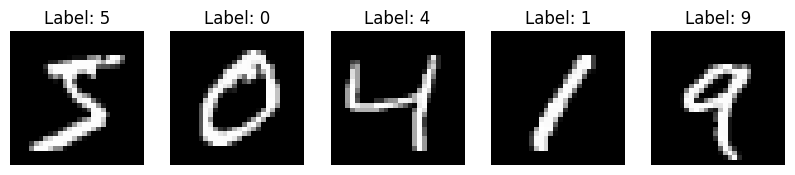

In [4]:
import matplotlib.pyplot as plt

print("Displaying 5 training samples...")

fig, ax = plt.subplots(1,5, figsize=(10,3))

for i in range(5):
    image, label = train_data[i]
    ax[i].imshow(image.squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {label}")
    ax[i].axis("off")

plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [5]:
from torch.utils.data import DataLoader

print("Creating DataLoaders...")

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

print(f"Train batches: {len(train_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Creating DataLoaders...
Train batches: 1875
Test batches: 313


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [8]:
import torch.nn as nn
import torch

print("Building TinyVGG CNN model...")

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

class TinyVGG(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(10,10,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(10,10,kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(10,10,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(10*4*4,10)
        )

    def forward(self,x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

model = TinyVGG().to(device)

print(model)
print(f"Using device: {device}")

Building TinyVGG CNN model...
TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160, out_features=10, bias=True)
  )
)
Using device: cuda


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [9]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

loss_fn = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

print("Starting training...")

epochs = 5

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1} | Training Loss: {train_loss:.4f}")

Starting training...
Epoch 1 | Training Loss: 519.3555
Epoch 2 | Training Loss: 211.3286
Epoch 3 | Training Loss: 161.9896
Epoch 4 | Training Loss: 135.4280
Epoch 5 | Training Loss: 119.2063


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

Making predictions on test samples...


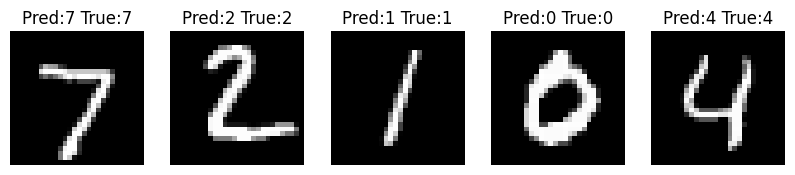

In [10]:
print("Making predictions on test samples...")

model.eval()

fig, ax = plt.subplots(1,5, figsize=(10,3))

for i in range(5):
    img, label = test_data[i]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))

    predicted = pred.argmax().item()

    ax[i].imshow(img.squeeze(), cmap="gray")
    ax[i].set_title(f"Pred:{predicted} True:{label}")
    ax[i].axis("off")

plt.show()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

Generating confusion matrix...


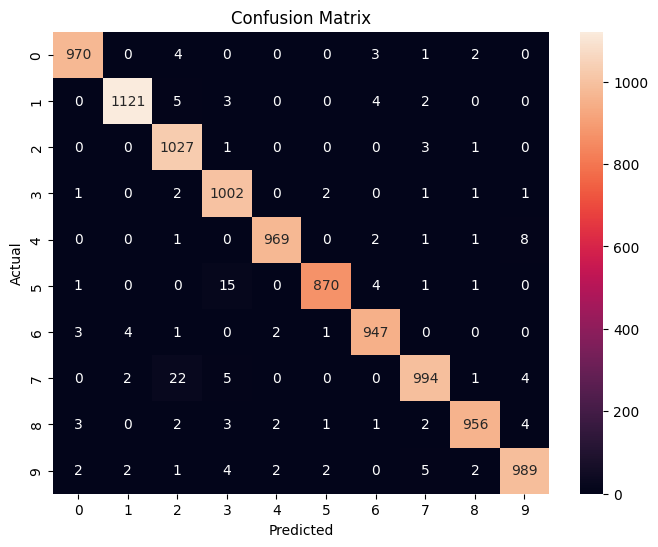

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("Generating confusion matrix...")

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for X,y in test_dataloader:
        X = X.to(device)
        preds = model(X)

        preds = preds.argmax(dim=1).cpu()

        y_pred.extend(preds)
        y_true.extend(y)

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [12]:
print("Testing Conv2D layer...")

x = torch.rand([1,3,64,64])

conv = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    stride=1,
    padding=1
)

output = conv(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Testing Conv2D layer...
Input shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 8, 64, 64])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [13]:
print("Loading FashionMNIST dataset...")

fashion_test = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

img, label = fashion_test[0]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))

predicted = pred.argmax().item()

print(f"Predicted label: {predicted}")
print(f"Actual label: {label}")

Loading FashionMNIST dataset...


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 192kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.0MB/s]

Predicted label: 2
Actual label: 9
